# Tier A dm_multiclass — rare-decay smoke test

Confusion matrix from `training-outputs/dm_multiclass_rare_test` (Z test preds).
Labels are Tier A (0–9) from truth daughter PDGs, not HPS reduced modes.

In [7]:
import os
import sys
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import mplhep as hep
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

# repo root on path if kernel cwd is notebooks/
REPO = "/user/u/urrejola/TauFCC/ml-tau-en-reg"
if REPO not in sys.path:
    sys.path.insert(0, REPO)

import enreg.tools.general as g

hep.style.use("CMS")
%matplotlib inline

In [8]:
import json

model_path = os.path.join(
    REPO,
    "training-outputs/dm_multiclass_rare_test/dm_multiclass/ParticleTransformer",
)

z_test_path = os.path.join(model_path, "z_test.parquet")
assert os.path.exists(z_test_path), z_test_path

z_full = ak.from_parquet(z_test_path)
z_test = z_full["dm_multiclass"]
print("fields:", z_test.fields)

y_true = ak.to_numpy(z_test.target)
y_pred = ak.to_numpy(z_test.pred)
# pred is already class index (0..9); if logits/probs appear later, argmax
if y_pred.ndim == 2:
    y_pred = np.argmax(y_pred, axis=1)

n_jets = len(y_true)
history_path = os.path.join(model_path, "history.json")
with open(history_path) as f:
    history = json.load(f)
n_epochs = len(history.get("loss_train", history.get("loss_validation", [])))

print(f"N jets: {n_jets:,}")
print(f"N epochs: {n_epochs}")
print("true classes:", np.unique(y_true))
print("pred classes:", np.unique(y_pred))


fields: ['pred', 'target']
N jets: 554,225
N epochs: 3
true classes: [0 1 2 3 4 5 6 7 8 9]
pred classes: [0 1 2 3 4 6 8 9]


In [9]:
class_names = list(g.TIER_A_CLASS_NAMES)  # pi, pi_pi0, ..., other
labels = list(g.TIER_A_CLASSES)  # 0..9

print(classification_report(
    y_true, y_pred, labels=labels, target_names=class_names, digits=3, zero_division=0
))
print("accuracy:", accuracy_score(y_true, y_pred))
print("macro F1:", f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0))
print("weighted F1:", f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0))

              precision    recall  f1-score   support

          pi      0.901     0.940     0.920     83900
      pi_pi0      0.922     0.943     0.932    220262
   pi_ge2pi0      0.842     0.910     0.875     88723
         3pi      0.892     0.912     0.902     82236
  3pi_ge1pi0      0.820     0.919     0.866     43002
           K      0.000     0.000     0.000      5961
       K_pi0      0.000     0.000     0.000      3738
       Kpipi      0.000     0.000     0.000      3091
       pi_K0      0.563     0.490     0.524     13165
       other      0.519     0.095     0.160     10147

    accuracy                          0.883    554225
   macro avg      0.546     0.521     0.518    554225
weighted avg      0.856     0.883     0.866    554225

accuracy: 0.8826505480626099
macro F1: 0.5179582823309612
weighted F1: 0.8662666599796368


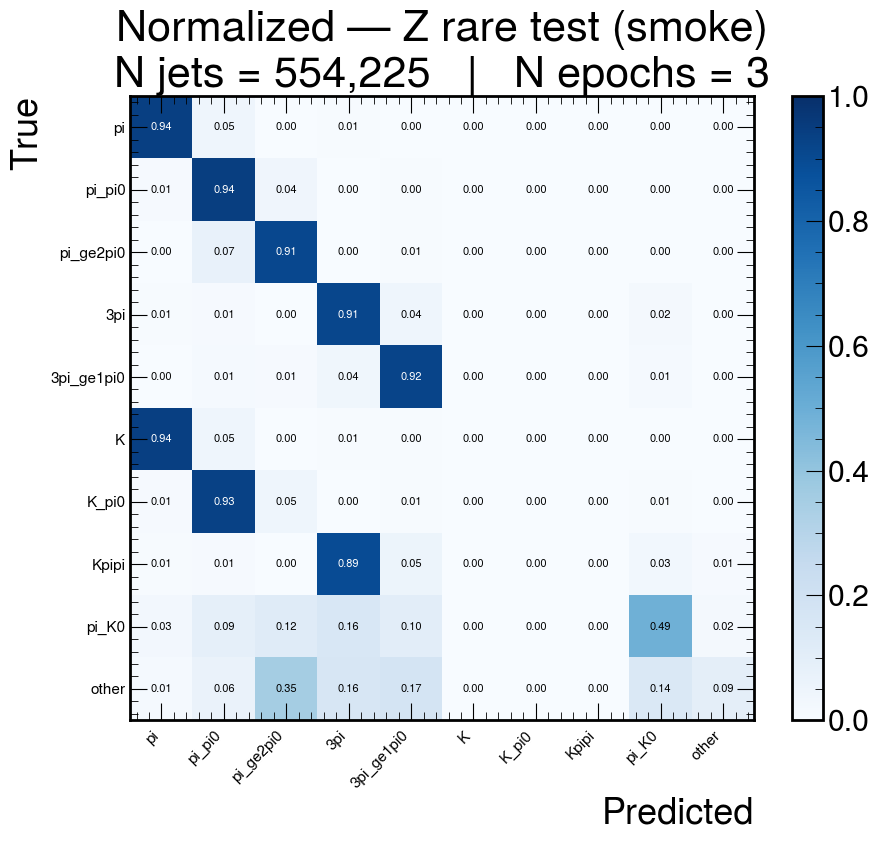

In [10]:
def plot_confusion_matrix(y_true, y_pred, dataset_name, class_names, labels, n_jets, n_epochs, figsize=(11, 9)):
    """Row-normalized CM: true (rows) vs predicted (cols)."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums > 0)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=11)
    ax.set_yticklabels(class_names, fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(
        f"Normalized — {dataset_name}\n"
        f"N jets = {n_jets:,}   |   N epochs = {n_epochs}"
    )

    thresh = 0.5
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            ax.text(
                j, i, f"{cm_norm[i, j]:.2f}",
                ha="center", va="center",
                color="white" if cm_norm[i, j] > thresh else "black",
                fontsize=8,
            )

    fig.tight_layout()
    plt.show()
    return cm, cm_norm


cm, cm_norm = plot_confusion_matrix(
    y_true, y_pred, "Z rare test (smoke)", class_names, labels, n_jets, n_epochs
)


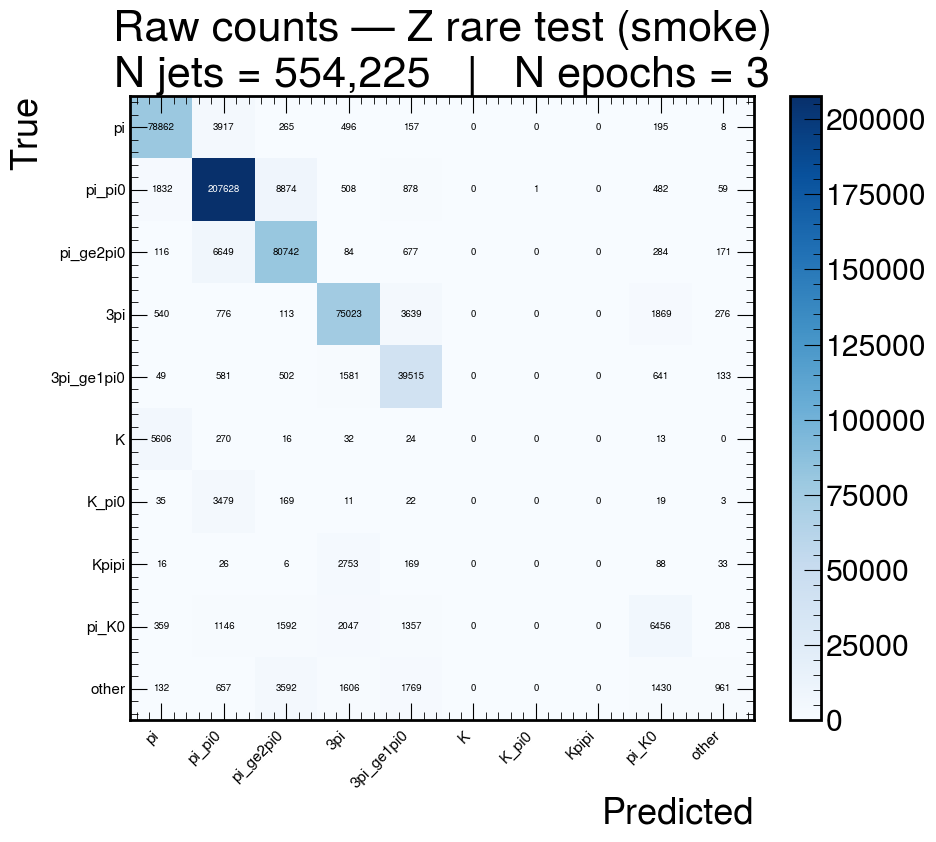

In [11]:
# Raw counts (same orientation)
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(class_names, fontsize=11)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(
    f"Raw counts — Z rare test (smoke)\n"
    f"N jets = {n_jets:,}   |   N epochs = {n_epochs}"
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", fontsize=7,
                color="white" if cm[i, j] > cm.max() / 2 else "black")

fig.tight_layout()
plt.show()


## Rare v2 training (`dm_multiclass_rare_v2`)

Same Tier A labels / Z test. More jets (`trainSize=40000`) and 10 epochs.  
Re-run the cells below once `z_test.parquet` exists under the v2 output dir (job may still be running).


In [ ]:
model_path_v2 = os.path.join(
    REPO,
    "training-outputs/dm_multiclass_rare_v2/dm_multiclass/ParticleTransformer",
)
z_test_path_v2 = os.path.join(model_path_v2, "z_test.parquet")
history_path_v2 = os.path.join(model_path_v2, "history.json")

if not os.path.exists(z_test_path_v2):
    print("v2 predictions not ready yet:")
    print(" ", z_test_path_v2)
    if os.path.exists(history_path_v2):
        with open(history_path_v2) as f:
            hist_v2_partial = json.load(f)
        print(f"  history exists — epochs finished so far: {len(hist_v2_partial.get('loss_train', []))}")
    elif os.path.isdir(model_path_v2):
        print("  model dir exists; listing:", os.listdir(model_path_v2))
    else:
        print("  output dir not created yet — training still starting / queued")
else:
    z_full_v2 = ak.from_parquet(z_test_path_v2)
    z_test_v2 = z_full_v2["dm_multiclass"]

    y_true_v2 = ak.to_numpy(z_test_v2.target)
    y_pred_v2 = ak.to_numpy(z_test_v2.pred)
    if y_pred_v2.ndim == 2:
        y_pred_v2 = np.argmax(y_pred_v2, axis=1)

    n_jets_v2 = len(y_true_v2)
    with open(history_path_v2) as f:
        history_v2 = json.load(f)
    n_epochs_v2 = len(history_v2.get("loss_train", history_v2.get("loss_validation", [])))

    print(f"v2 N jets: {n_jets_v2:,}")
    print(f"v2 N epochs: {n_epochs_v2}")
    print("v2 true classes:", np.unique(y_true_v2))
    print("v2 pred classes:", np.unique(y_pred_v2))
    print(classification_report(
        y_true_v2, y_pred_v2, labels=labels, target_names=class_names, digits=3, zero_division=0
    ))
    print("v2 accuracy:", accuracy_score(y_true_v2, y_pred_v2))
    print("v2 macro F1:", f1_score(y_true_v2, y_pred_v2, labels=labels, average="macro", zero_division=0))
    print("v2 weighted F1:", f1_score(y_true_v2, y_pred_v2, labels=labels, average="weighted", zero_division=0))


In [ ]:
# Normalized + raw-count CMs for v2 (skip if preds not ready)
if not os.path.exists(z_test_path_v2):
    print("Skip v2 plots — waiting for", z_test_path_v2)
else:
    cm_v2, cm_norm_v2 = plot_confusion_matrix(
        y_true_v2,
        y_pred_v2,
        "Z rare v2",
        class_names,
        labels,
        n_jets_v2,
        n_epochs_v2,
    )

    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(cm_v2, interpolation="nearest", cmap="Blues")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=11)
    ax.set_yticklabels(class_names, fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(
        f"Raw counts — Z rare v2\n"
        f"N jets = {n_jets_v2:,}   |   N epochs = {n_epochs_v2}"
    )
    for i in range(cm_v2.shape[0]):
        for j in range(cm_v2.shape[1]):
            ax.text(
                j, i, f"{cm_v2[i, j]}",
                ha="center", va="center", fontsize=7,
                color="white" if cm_v2[i, j] > cm_v2.max() / 2 else "black",
            )
    fig.tight_layout()
    plt.show()
